In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Financialdata_Segmented.csv")

In [3]:
numeric_df = df.select_dtypes(include=np.number)
remove_columns = [
    "Cluster",
    "Performance"
]
features = numeric_df.drop(
    columns=[col for col in remove_columns if col in numeric_df.columns],
    errors="ignore"
)
print(features.shape)

(3808, 216)


In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [5]:
pca = PCA()
principal_components = pca.fit_transform(scaled_data)

In [6]:
explained_variance = pd.DataFrame({
    "Principal Component":
    [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance":
    pca.explained_variance_ratio_,
    "Cumulative Variance":
    np.cumsum(pca.explained_variance_ratio_)
})
print(explained_variance.head(15))

   Principal Component  Explained Variance  Cumulative Variance
0                  PC1            0.214318             0.214318
1                  PC2            0.073529             0.287847
2                  PC3            0.056748             0.344595
3                  PC4            0.043695             0.388291
4                  PC5            0.037349             0.425639
5                  PC6            0.028708             0.454347
6                  PC7            0.024976             0.479324
7                  PC8            0.022808             0.502132
8                  PC9            0.022384             0.524516
9                 PC10            0.019780             0.544296
10                PC11            0.017626             0.561922
11                PC12            0.016026             0.577949
12                PC13            0.014966             0.592914
13                PC14            0.014609             0.607524
14                PC15            0.0135

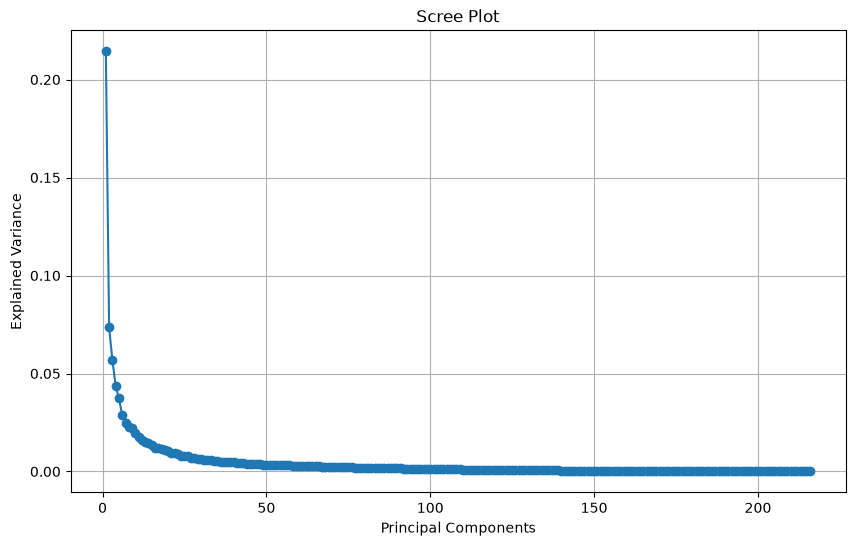

In [7]:
plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

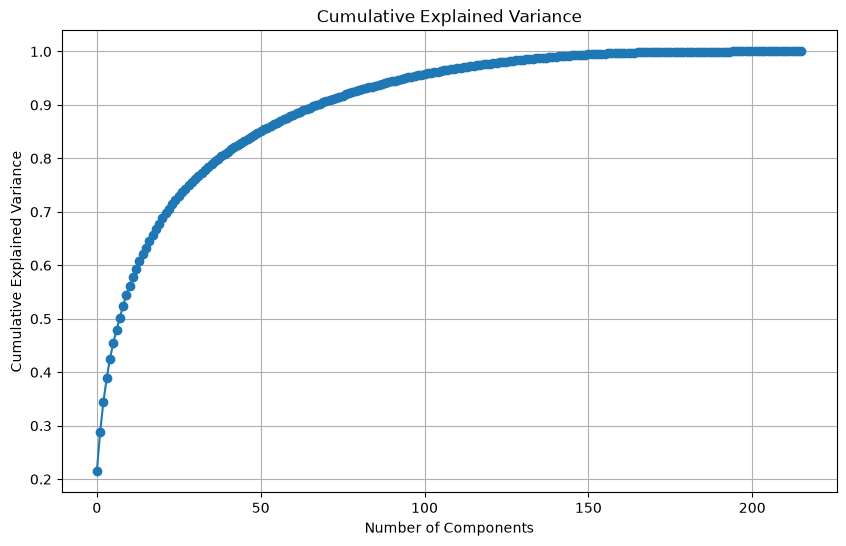

In [8]:
plt.figure(figsize=(10,6))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [9]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)
if "Cluster" in df.columns:
    pca_df["Cluster"] = df["Cluster"]

print(pca_df.head())

         PC1       PC2  Cluster
0  15.369798 -2.385334        1
1   5.164374 -0.371341        0
2  13.897641 -5.227074        0
3   8.962987 -5.664596        1
4  15.195271 -3.387326        0


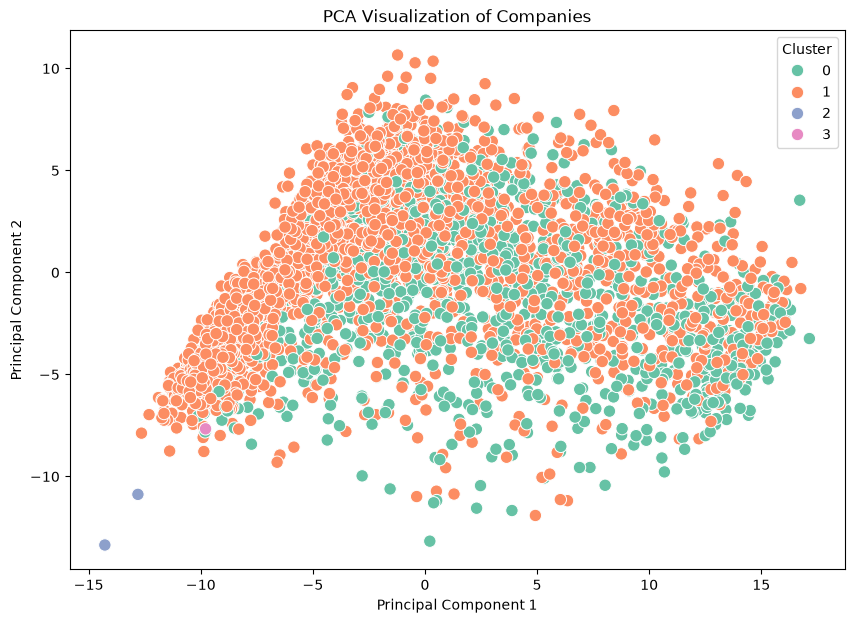

In [10]:
plt.figure(figsize=(10,7))
if "Cluster" in pca_df.columns:
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="Set2",
        s=80
    )
    plt.legend(title="Cluster")
else:
    plt.scatter(
        pca_df["PC1"],
        pca_df["PC2"]
    )
plt.title("PCA Visualization of Companies")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=features.columns
)
print(loadings)

                             PC1       PC2
Revenue                 0.124730 -0.078964
Revenue_Growth         -0.008606  0.038557
Cost_of_Revenue         0.110958 -0.085744
Gross_Profit            0.127797 -0.061059
R&D_Expenses           -0.014092 -0.054327
...                          ...       ...
Class                   0.005392  0.049253
Operating_Margin        0.014356  0.029728
Financial_Health_Score  0.015330  0.032130
PCA1                    0.032024  0.032187
PCA2                    0.061156 -0.031685

[216 rows x 2 columns]


In [12]:
top_pc1 = loadings["PC1"].abs().sort_values(
    ascending=False
)
print(top_pc1.head(15))

EBITDA                       0.131148
Gross_Profit                 0.127797
EBIT                         0.127645
Operating_Income             0.126754
Revenue                      0.124730
Operating_Cash_Flow          0.124314
Earnings_before_Tax          0.123439
Net_Income                   0.121047
Consolidated_Income          0.121041
Net_Income_Com               0.120474
Total_current_liabilities    0.119356
Total_assets                 0.119126
Operating_Expenses           0.118038
Market_Cap                   0.117056
Total_non_current_assets     0.117009
Name: PC1, dtype: float64


In [13]:
top_pc2 = loadings["PC2"].abs().sort_values(
    ascending=False
)
print(top_pc2.head(15))

netProfitMargin                       0.170810
Earnings_Before_Tax_Margin            0.169932
Profit_Margin                         0.165174
ebitperRevenue                        0.156506
eBITperRevenue                        0.156506
EBIT_Margin                           0.154852
pretaxProfitMargin                    0.153570
capitalExpenditureCoverageRatios      0.139005
Earnings_Yield                        0.138952
Free_Cash_Flow_margin                 0.136922
returnOnCapitalEmployed               0.128737
ROIC                                  0.128737
dividendpaidAndCapexCoverageRatios    0.125647
Return_on_Tangible_Assets             0.116829
returnOnAssets                        0.116829
Name: PC2, dtype: float64


In [14]:
pca_df.to_csv(
    "Financialdata_PCA.csv",
    index=False
)
print("PCA Completed Successfully!")

PCA Completed Successfully!
